Atrial Fibrillation Classification from Short Single-Lead ECG Recordings

This notebook presents a machine-learning workflow for classifying short single-lead ECG recordings into rhythm categories using the PhysioNet/CinC 2017 dataset.

Overview of the 2017 PhysioNet/CinC dataset

The 2017 PhysioNet/CinC Challenge focuses on classifying a short single-lead ECG recording (30-60 seconds) into four categories: 
1) Normal sinus rhythm, 
2) Atrial fibrillation (AF), 
3) Other rhythm, and 
4) Too noisy to classify. 

AF is a common and serious arrhythmia associated with increased mortality and morbidity. Accurate detection of AF remains challenging due to its episodic nature and potential noise in ECG signals.

The workflow includes ECG signal loading, preprocessing, segmentation, feature extraction, feature table creation, exploratory checks, and later model training and evaluation. The goal is to compare machine-learning approaches for rhythm classification while keeping the workflow interpretable.

In [1]:
# Importing libraries

import os
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.io
from scipy.signal import butter, filtfilt
from scipy.stats import skew, kurtosis, entropy
import neurokit2 as nk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

import lightgbm as lgb

In [2]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

Define dataset path

Configuration

The dataset location is read from an environment variable (`AF_DATA_DIR`) instead of being hardcoded, so this notebook is portable across machines.

Set the environment variable before launching Jupyter. For example:

```bash
export AF_DATA_DIR="/path/to/af-classification-from-a-short-single-lead-ecg-recording-the-physionet-computing-in-cardiology-challenge-2017-1.0.0"
```

Expected dataset structure:

```text
AF_DATA_DIR/
├── REFERENCE-v3.csv
└── extracted_training2017/
    └── training2017/
        ├── A00001.mat
        ├── A00002.mat
        └── ...
```


In [4]:
base_path = os.environ.get(
    "AF_DATA_DIR",
    os.path.join("data", "raw")
)

# Folder containing the extracted ECG .mat files
extracted_training_path = os.path.join(
    base_path,
    "extracted_training2017",
    "training2017"
)

# CSV file containing ECG record IDs and rhythm labels
labels_path = os.path.join(base_path, "REFERENCE-v3.csv")


ECG Signal Preprocessing and Segmentation Functions

In [5]:
# Helper functions for ECG loading and preprocessing


def load_ecg_signal(file_path):
    """
    Load a single-lead ECG signal from a MATLAB .mat file.

    The PhysioNet/CinC 2017 ECG files store the waveform values
    under the key 'val'. Since these are single-lead ECG recordings,
    we extract the first row of the 'val' array.
    """
    mat_data = scipy.io.loadmat(file_path)
    return mat_data["val"][0]


def filter_signal(signal, sampling_rate=300):
    """
    Apply a bandpass filter to the ECG signal.

    The 0.5 Hz lower cutoff helps remove slow baseline drift.
    The 50 Hz upper cutoff helps reduce high-frequency noise.
    filtfilt applies the filter forward and backward to reduce phase shift.
    """
    lowcut = 0.5      # Lower cutoff frequency in Hz
    highcut = 50.0   # Upper cutoff frequency in Hz

    nyquist = 0.5 * sampling_rate
    low = lowcut / nyquist
    high = highcut / nyquist

    # First-order Butterworth bandpass filter
    b, a = butter(1, [low, high], btype="band")

    # If the signal is unexpectedly too short, return it unfiltered
    # to avoid filtfilt errors.
    if len(signal) <= 3 * max(len(a), len(b)):
        return signal

    return filtfilt(b, a, signal)


def zscore_normalization(signal):
    """
    Z-score normalize the ECG signal.

    This centers the signal around 0 and scales it by its standard deviation,
    making signals more comparable across recordings.
    """
    signal_mean = np.mean(signal)
    signal_std = np.std(signal)

    # Avoid division by zero for flat or near-flat signals.
    if signal_std == 0:
        return signal - signal_mean

    return (signal - signal_mean) / signal_std


def correct_inverted_signal(signal):
    """
    Correct potentially inverted ECG signals using a simple polarity heuristic.

    If the largest negative peak has greater absolute magnitude than the
    largest positive peak, the signal is flipped.
    """
    if np.abs(np.min(signal)) > np.abs(np.max(signal)):
        signal = -signal

    return signal


def sliding_window(signal, window_size, step_size):
    """
    Split an ECG signal into fixed-length overlapping windows.

    Parameters
    ----------
    signal : array-like
        Preprocessed ECG signal.
    window_size : int
        Number of samples in each window.
    step_size : int
        Number of samples to move forward between windows.

    Returns
    -------
    list
        A list of ECG signal windows.
    """
    windows = []

    for start in range(0, len(signal) - window_size + 1, step_size):
        window = signal[start:start + window_size]
        windows.append(window)

    return windows

In [6]:
# 4. Feature extraction functions

def calculate_poincare(rr_intervals):
    """
    Calculate Poincaré plot features from RR intervals.

    SD1 captures short-term beat-to-beat variability.
    SD2 captures longer-term RR interval variability.
    The SD1/SD2 ratio summarizes the shape of RR interval dispersion.
    """
    rr_intervals = np.asarray(rr_intervals, dtype=float)

    if len(rr_intervals) < 2:
        return 0.0, 0.0, 0.0

    diff_rr = np.diff(rr_intervals)

    sd1 = np.sqrt(np.var(diff_rr) / 2)

    sd2_value = 2 * np.var(rr_intervals) - sd1**2
    sd2 = np.sqrt(max(sd2_value, 0))

    poincare_ratio = sd1 / sd2 if sd2 != 0 else 0.0

    return sd1, sd2, poincare_ratio


def extract_features(signal, sampling_rate=300):
    """
    Extract statistical, heart-rate-variability, frequency-domain,
    and signal-complexity features from a preprocessed ECG segment.
    """
    signal = np.asarray(signal, dtype=float)

    # Detect R-peaks and calculate RR intervals.
    # If R-peak detection fails for a noisy segment, use an empty RR array.
    try:
        rpeaks = nk.ecg_findpeaks(signal, sampling_rate=sampling_rate)["ECG_R_Peaks"]
        rr_intervals = np.diff(rpeaks) / sampling_rate
    except Exception:
        rpeaks = np.array([])
        rr_intervals = np.array([])

    # Heart-rate-variability features
    mean_rr = np.mean(rr_intervals) if len(rr_intervals) > 0 else 0.0
    sdnn = np.std(rr_intervals) if len(rr_intervals) > 0 else 0.0
    rmssd = (
        np.sqrt(np.mean(np.square(np.diff(rr_intervals))))
        if len(rr_intervals) > 1
        else 0.0
    )

    # Signal distribution features
    mean_abs_signal = np.abs(np.mean(signal))
    std_dev = np.std(signal)
    skewness = skew(signal)
    kurt = kurtosis(signal)

    # Frequency-domain features using the real-valued FFT
    power_spectrum = np.abs(np.fft.rfft(signal)) ** 2
    freqs = np.fft.rfftfreq(len(signal), d=1 / sampling_rate)

    dominant_freq = freqs[np.argmax(power_spectrum)] if len(power_spectrum) > 0 else 0.0
    total_power = np.sum(power_spectrum)

    # Poincaré features from RR intervals
    sd1, sd2, poincare_ratio = calculate_poincare(rr_intervals)

    # Amplitude and signal-complexity features
    max_amplitude = np.max(signal)
    mean_amplitude = np.mean(signal)
    amplitude_sd = np.std(signal)
    signal_energy = np.sum(signal**2)

    abs_signal = np.abs(signal)
    if np.sum(abs_signal) == 0:
        signal_entropy = 0.0
    else:
        signal_entropy = entropy(abs_signal)

    return {
        "mean_rr": mean_rr,
        "sdnn": sdnn,
        "rmssd": rmssd,
        "mean": mean_abs_signal,
        "std_dev": std_dev,
        "skewness": skewness,
        "kurtosis": kurt,
        "dominant_freq": dominant_freq,
        "total_power": total_power,
        "poincare_sd1": sd1,
        "poincare_sd2": sd2,
        "poincare_ratio": poincare_ratio,
        "max_amplitude": max_amplitude,
        "mean_amplitude": mean_amplitude,
        "amplitude_sd": amplitude_sd,
        "signal_entropy": signal_entropy,
        "signal_energy": signal_energy,
    }

Feature Extraction

This section loops through the ECG .mat files, matches each recording with its rhythm label, applies preprocessing, splits the recording into overlapping windows, and extracts features from each segment.

Each extracted segment is stored as one row in the feature dataset.

In [7]:
# Build ECG feature dataset

# ECG preprocessing parameters
sampling_rate = 300      # Sampling frequency in Hz
window_size = 3000       # 10-second ECG windows at 300 Hz
step_size = 1500         # 5-second step size, creating 50% overlap


# Load label file

labels_df = pd.read_csv(
    labels_path,
    header=None,
    names=["record", "label"]
)

print("Label file shape:", labels_df.shape)
print(labels_df.head())

# Extract features from ECG files


feature_data = []
processed_records = set()
skipped_records = []

mat_files = sorted([
    file_name for file_name in os.listdir(extracted_training_path)
    if file_name.endswith(".mat")
])

for file_name in mat_files:
    record_name = os.path.splitext(file_name)[0]

    # Avoid processing the same ECG record more than once
    if record_name in processed_records:
        continue

    # Match ECG file with its rhythm label
    label_row = labels_df[labels_df["record"] == record_name]

    if label_row.empty:
        skipped_records.append(record_name)
        continue

    label = label_row.iloc[0]["label"]
    file_path = os.path.join(extracted_training_path, file_name)

    try:
        # Load and preprocess ECG signal
        ecg_signal = load_ecg_signal(file_path)
        filtered_signal = filter_signal(ecg_signal, sampling_rate=sampling_rate)
        normalized_signal = zscore_normalization(filtered_signal)
        corrected_signal = correct_inverted_signal(normalized_signal)

        # Split ECG recording into fixed-length overlapping windows
        segments = sliding_window(
            corrected_signal,
            window_size=window_size,
            step_size=step_size
        )

        # Extract features from each ECG segment
        for segment_id, segment in enumerate(segments):
            features = extract_features(segment, sampling_rate=sampling_rate)

            # Keep record identifier for record-level train/test splitting later
            features["record"] = record_name
            features["segment_id"] = segment_id
            features["label"] = label

            feature_data.append(features)

        processed_records.add(record_name)

    except Exception as error:
        skipped_records.append(record_name)
        print(f"Skipped record {record_name} due to error: {error}")


# Create feature DataFrame

features_df = pd.DataFrame(feature_data)

if features_df.empty:
    raise ValueError("No features were extracted. Check data paths and ECG files.")

# Reorder identifier and label columns for readability
id_columns = ["record", "segment_id", "label"]
feature_columns = [col for col in features_df.columns if col not in id_columns]
features_df = features_df[id_columns + feature_columns]


# Save extracted features


output_dir = os.path.join("data", "processed")
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "features_data_simplified.csv")
features_df.to_csv(output_path, index=False)

print(f"Processed ECG records: {len(processed_records)}")
print(f"Extracted ECG segments: {features_df.shape[0]}")
print(f"Number of extracted features per segment: {len(feature_columns)}")
print(f"Skipped records: {len(skipped_records)}")
print(f"Features saved to: {output_path}")

Label file shape: (8528, 2)
   record label
0  A00001     N
1  A00002     N
2  A00003     N
3  A00004     A
4  A00005     A
Processed ECG records: 8528
Extracted ECG segments: 46065
Number of extracted features per segment: 17
Skipped records: 0
Features saved to: data\processed\features_data_simplified.csv


In [8]:
features_df.head(10)

,record,segment_id,label,mean_rr,sdnn,rmssd,mean,std_dev,skewness,kurtosis,dominant_freq,total_power,poincare_sd1,poincare_sd2,poincare_ratio,max_amplitude,mean_amplitude,amplitude_sd,signal_entropy,signal_energy
0,A00001,0,N,0.784722,0.030746,0.027816,0.012863,1.145227,1.715959,6.542878,2.5,5.903437e+06,0.018985,0.039117,0.485330,5.478928,-0.012863,1.145227,7.421790,3935.128430
1,A00001,1,N,0.792727,0.019788,0.021909,0.004314,1.032427,2.613354,9.391085,2.5,4.796746e+06,0.015312,0.023423,0.653685,5.478928,0.004314,1.032427,7.363615,3197.774819
2,A00001,2,N,0.765000,0.029234,0.022247,0.002247,0.913694,3.587445,14.606152,4.0,3.756815e+06,0.015520,0.038320,0.405008,5.512445,-0.002247,0.913694,7.337872,2504.528037
3,A00001,3,N,0.739231,0.016700,0.020435,0.010901,0.953118,3.520505,13.807951,2.7,4.089022e+06,0.014416,0.018707,0.770633,5.512445,0.010901,0.953118,7.307477,2725.658414
4,A00001,4,N,0.723846,0.042201,0.048743,0.015110,0.923699,3.595783,14.715419,4.1,3.841543e+06,0.033366,0.049483,0.674283,5.558456,0.015110,0.923699,7.318463,2560.343533
5,A00002,0,N,0.848485,0.255736,0.342343,0.014776,0.849555,3.795347,25.566251,0.9,3.249808e+06,0.241079,0.269597,0.894219,9.746492,0.014776,0.849555,7.470849,2165.883920
6,A00002,1,N,0.841212,0.256197,0.344537,0.027238,0.806535,4.271390,31.421459,1.0,2.933922e+06,0.243049,0.268703,0.904527,9.746492,-0.027238,0.806535,7.477177,1953.722281
7,A00002,2,N,0.887000,0.222638,0.306852,0.003324,1.166513,2.525098,11.522653,1.0,6.123486e+06,0.214289,0.230685,0.928927,8.697267,-0.003324,1.166513,7.384278,4082.289507
8,A00002,3,N,0.790000,0.250470,0.328195,0.023207,1.315260,2.491144,10.164114,1.1,7.789436e+06,0.232059,0.267617,0.867131,9.849216,0.023207,1.315260,7.371818,5191.341733
9,A00002,4,N,0.872667,0.218895,0.282926,0.011452,0.957677,3.710070,21.860396,4.1,4.128331e+06,0.200058,0.236235,0.846859,9.849216,-0.011452,0.957677,7.338277,2751.826573


In [9]:
features_df.tail(10)

,record,segment_id,label,mean_rr,sdnn,rmssd,mean,std_dev,skewness,kurtosis,dominant_freq,total_power,poincare_sd1,poincare_sd2,poincare_ratio,max_amplitude,mean_amplitude,amplitude_sd,signal_entropy,signal_energy
46055,A08527,0,N,0.609286,0.013224,0.012943,0.041559,0.715984,0.724489,3.345350,0.9,2.322393e+06,0.009123,0.016326,0.558820,4.022235,-0.041559,0.715984,7.588493,1543.080797
46056,A08527,1,N,0.591333,0.066308,0.104319,0.002253,1.194587,2.172663,20.874393,1.3,6.421713e+06,0.073703,0.057978,1.271228,11.648585,-0.002253,1.194587,7.421683,4281.126892
46057,A08527,2,N,0.618222,0.162243,0.242827,0.028306,1.410988,1.347243,10.897837,1.2,8.966203e+06,0.171703,0.152195,1.128178,11.648585,0.028306,1.410988,7.500547,5975.065292
46058,A08527,3,N,0.645476,0.146886,0.227851,0.028195,1.000373,0.606999,5.315963,0.7,4.510516e+06,0.161101,0.131140,1.228461,5.556095,0.028195,1.000373,7.512921,3004.625792
46059,A08527,4,N,0.622667,0.028185,0.018366,0.013253,0.702692,0.995238,2.594892,0.7,2.223571e+06,0.012977,0.037687,0.344325,3.198815,0.013253,0.702692,7.619624,1481.853911
46060,A08528,0,N,0.970000,0.022662,0.031269,0.014835,1.065979,1.429136,4.654798,1.0,5.115383e+06,0.022111,0.023201,0.953025,6.040933,-0.014835,1.065979,7.582037,3409.594995
46061,A08528,1,N,0.971852,0.020068,0.028699,0.002148,0.917309,1.925789,8.053577,1.0,3.786595e+06,0.020188,0.019948,1.012012,5.168806,-0.002148,0.917309,7.551246,2524.382582
46062,A08528,2,N,0.943333,0.024140,0.027814,0.009081,0.898697,2.004171,8.466156,3.2,3.635195e+06,0.019488,0.028030,0.695258,5.168806,0.009081,0.898697,7.515948,2423.215671
46063,A08528,3,N,0.918667,0.021766,0.030082,0.017484,1.016190,1.174553,4.075094,1.1,4.649643e+06,0.021231,0.022289,0.952530,5.128969,0.017484,1.016190,7.556427,3098.844904
46064,A08528,4,N,0.905667,0.043895,0.038378,0.005754,1.027471,1.091636,3.528238,1.1,4.750934e+06,0.025542,0.056579,0.451444,5.128969,0.005754,1.027471,7.575383,3167.189334


Data Quality Check: Missing Values and Duplicate Rows

In [10]:
features_df.isnull().sum()

record            0
segment_id        0
label             0
mean_rr           0
sdnn              0
rmssd             0
mean              0
std_dev           0
skewness          0
kurtosis          0
dominant_freq     0
total_power       0
poincare_sd1      0
poincare_sd2      0
poincare_ratio    0
max_amplitude     0
mean_amplitude    0
amplitude_sd      0
signal_entropy    0
signal_energy     0
dtype: int64

In [11]:
# Check for exact duplicate rows
duplicate_count = features_df.duplicated().sum()
print("Number of exact duplicate rows:", duplicate_count)

# Remove exact duplicate rows if present
if duplicate_count > 0:
    features_df = features_df.drop_duplicates(keep="first").reset_index(drop=True)

print("Feature dataset shape after duplicate check:", features_df.shape)

Number of exact duplicate rows: 0
Feature dataset shape after duplicate check: (46065, 20)


In [12]:
features_df.shape

(46065, 20)

In [13]:
print(features_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46065 entries, 0 to 46064
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record          46065 non-null  object 
 1   segment_id      46065 non-null  int64  
 2   label           46065 non-null  object 
 3   mean_rr         46065 non-null  float64
 4   sdnn            46065 non-null  float64
 5   rmssd           46065 non-null  float64
 6   mean            46065 non-null  float64
 7   std_dev         46065 non-null  float64
 8   skewness        46065 non-null  float64
 9   kurtosis        46065 non-null  float64
 10  dominant_freq   46065 non-null  float64
 11  total_power     46065 non-null  float64
 12  poincare_sd1    46065 non-null  float64
 13  poincare_sd2    46065 non-null  float64
 14  poincare_ratio  46065 non-null  float64
 15  max_amplitude   46065 non-null  float64
 16  mean_amplitude  46065 non-null  float64
 17  amplitude_sd    46065 non-null 

In [14]:
print("\nLabel Distribution:")
print(features_df['label'].value_counts())


Label Distribution:
label
N    27039
O    13939
A     4075
~     1012
Name: count, dtype: int64


The label distribution shows an imbalance in the dataset, with the majority of instances belonging to the 'N' (Normal) class, which has 27,039 samples. This is followed by the 'O' (Other) class with 13,939 samples. The 'A' (Atrial Fibrillation) class has 4,075 samples, and the '~' (Noisy) class has the fewest samples at 1,012. This uneven distribution suggests that the model may be more exposed to normal and other types of signals, while the Atrial Fibrillation and noisy classes are underrepresented, potentially leading to challenges in detecting rarer events like atrial fibrillation.

Visual Quality Check: Raw vs Filtered ECG Signal

This section compares a raw ECG segment with the filtered version of the same segment. The purpose is to verify that the bandpass filter does not distort the main ECG waveform while reducing unwanted low- or high-frequency components when present.

For some clean ECG recordings, the visual difference between the raw and filtered signals may be small. In that case, the plot still serves as a quality-control check confirming that the preprocessing step preserves the overall signal morphology.

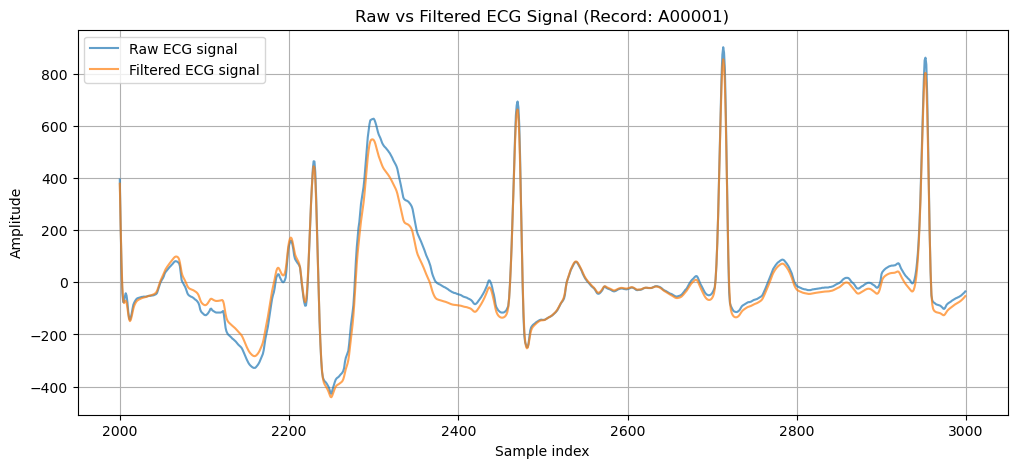

In [15]:
# Visual quality check: raw vs filtered ECG signal

# Select one ECG record that was successfully processed
record_name = features_df["record"].iloc[0]

# Load the raw ECG signal
file_path = os.path.join(extracted_training_path, f"{record_name}.mat")
ecg_signal = load_ecg_signal(file_path)

# Apply the same bandpass filter used during preprocessing
filtered_signal = filter_signal(ecg_signal, sampling_rate=sampling_rate)

# Select a short segment for visual inspection
segment_length = 1000
start_index = min(2000, max(len(ecg_signal) - segment_length, 0))
end_index = min(start_index + segment_length, len(ecg_signal))

# Plot raw and filtered signals together
plt.figure(figsize=(12, 5))
plt.plot(
    range(start_index, end_index),
    ecg_signal[start_index:end_index],
    label="Raw ECG signal",
    alpha=0.7
)
plt.plot(
    range(start_index, end_index),
    filtered_signal[start_index:end_index],
    label="Filtered ECG signal",
    alpha=0.7
)

plt.title(f"Raw vs Filtered ECG Signal (Record: {record_name})")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

Visual Quality Check: R-Peak Detection on ECG Segments

This section visualizes two sliding-window ECG segments from the same recording and overlays the detected R-peaks. This is an important quality-control step because several extracted features depend on RR intervals, which are calculated from the detected R-peaks.

If R-peaks are not detected correctly, heart-rate-variability features such as mean RR, SDNN, RMSSD, and Poincaré features may be unreliable.

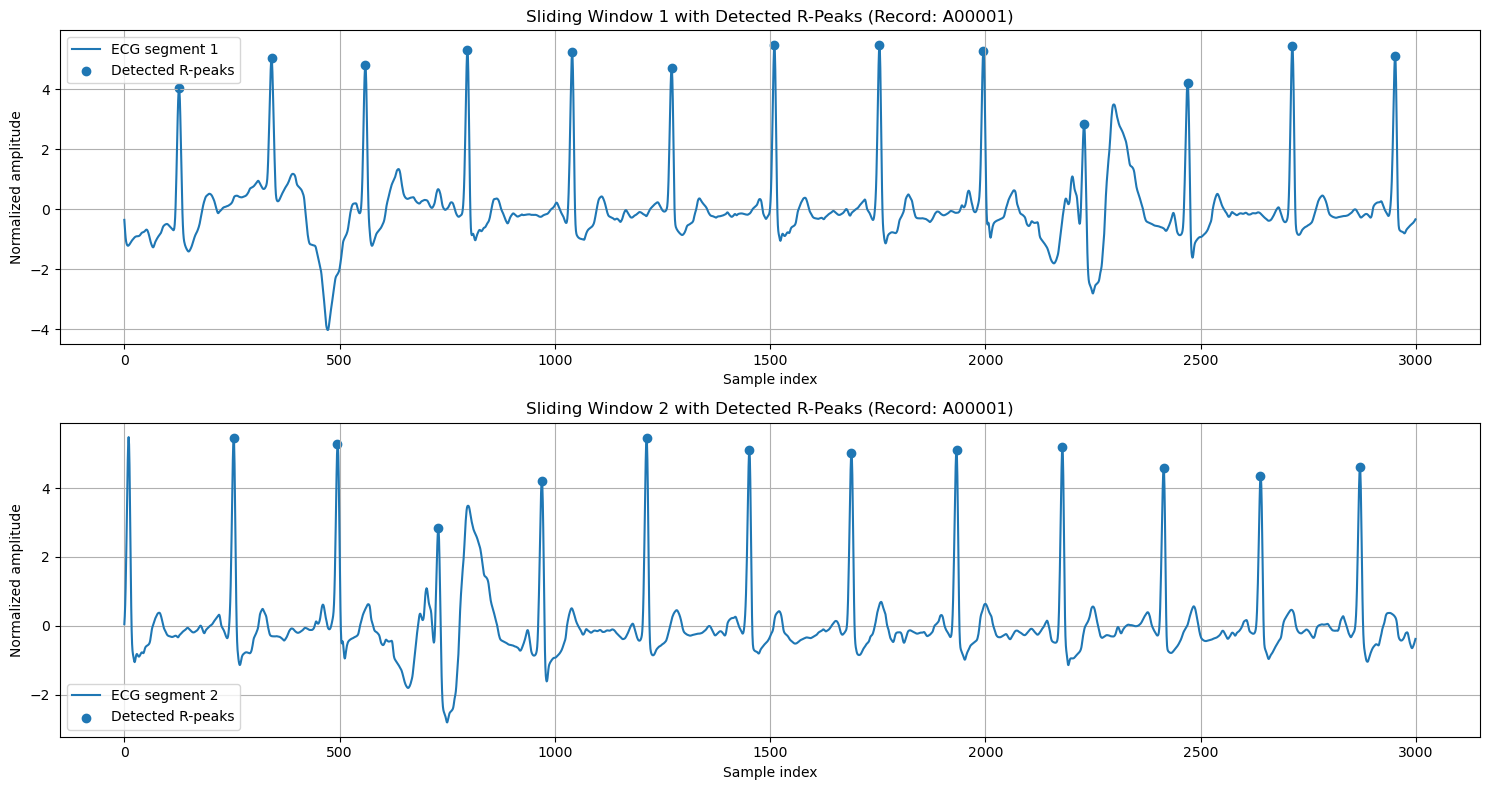

In [16]:
# 9. Visual quality check: R-peak detection on ECG segments

# Apply the same preprocessing sequence used during feature extraction
normalized_signal = zscore_normalization(filtered_signal)
corrected_signal = correct_inverted_signal(normalized_signal)

# Create sliding-window ECG segments
segments = sliding_window(corrected_signal, window_size, step_size)

# Check that at least two segments are available for visualization
if len(segments) < 2:
    raise ValueError("This ECG recording does not contain enough data for two sliding-window segments.")

# Select two consecutive ECG segments from the same record
segment_1 = segments[0]
segment_2 = segments[1]

# Detect R-peaks in both ECG segments
_, peaks_info_1 = nk.ecg_peaks(segment_1, sampling_rate=sampling_rate)
_, peaks_info_2 = nk.ecg_peaks(segment_2, sampling_rate=sampling_rate)

rpeaks_1 = peaks_info_1["ECG_R_Peaks"]
rpeaks_2 = peaks_info_2["ECG_R_Peaks"]

# Plot both segments with detected R-peaks
plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
plt.plot(segment_1, label="ECG segment 1")
plt.scatter(rpeaks_1, segment_1[rpeaks_1], label="Detected R-peaks")
plt.title(f"Sliding Window 1 with Detected R-Peaks (Record: {record_name})")
plt.xlabel("Sample index")
plt.ylabel("Normalized amplitude")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(segment_2, label="ECG segment 2")
plt.scatter(rpeaks_2, segment_2[rpeaks_2], label="Detected R-peaks")
plt.title(f"Sliding Window 2 with Detected R-Peaks (Record: {record_name})")
plt.xlabel("Sample index")
plt.ylabel("Normalized amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
# Display summary statistics
non_feature_columns = ["record", "segment_id", "label"]

feature_columns = [
    col for col in features_df.columns
    if col not in non_feature_columns
]

summary_statistics = features_df[feature_columns].describe().T

summary_statistics

,count,mean,std,min,25%,50%,75%,max
mean_rr,46065.0,8.313091e-01,1.861332e-01,0.000000e+00,7.250000e-01,8.266667e-01,9.300000e-01,9.453333e+00
sdnn,46065.0,9.511644e-02,1.260874e-01,0.000000e+00,1.528657e-02,4.248366e-02,1.480839e-01,3.045000e+00
rmssd,46065.0,1.309417e-01,1.972382e-01,0.000000e+00,1.534124e-02,4.510790e-02,2.026217e-01,6.090000e+00
mean,46065.0,1.577874e-02,1.678150e-02,6.246674e-07,4.771827e-03,1.082144e-02,2.093790e-02,2.465119e-01
std_dev,46065.0,9.523496e-01,2.163092e-01,6.963712e-02,8.869744e-01,9.760753e-01,1.022602e+00,2.395286e+00
skewness,46065.0,1.629992e+00,1.923260e+00,-7.466181e+00,5.274445e-01,1.846432e+00,3.052858e+00,1.525138e+01
kurtosis,46065.0,9.951815e+00,8.791348e+00,-8.681865e-01,4.161038e+00,8.370625e+00,1.382637e+01,3.045586e+02
dominant_freq,46065.0,2.659399e+00,1.902189e+00,0.000000e+00,1.100000e+00,2.400000e+00,3.800000e+00,2.500000e+01
total_power,46065.0,4.296689e+06,1.919637e+06,2.263278e+04,3.545823e+06,4.289743e+06,4.708762e+06,2.581891e+07
poincare_sd1,46065.0,9.072724e-02,1.315658e-01,0.000000e+00,1.044829e-02,3.108023e-02,1.413821e-01,3.649850e+00


Segment-level label distribution:
label
A     4075
N    27039
O    13939
~     1012
Name: count, dtype: int64


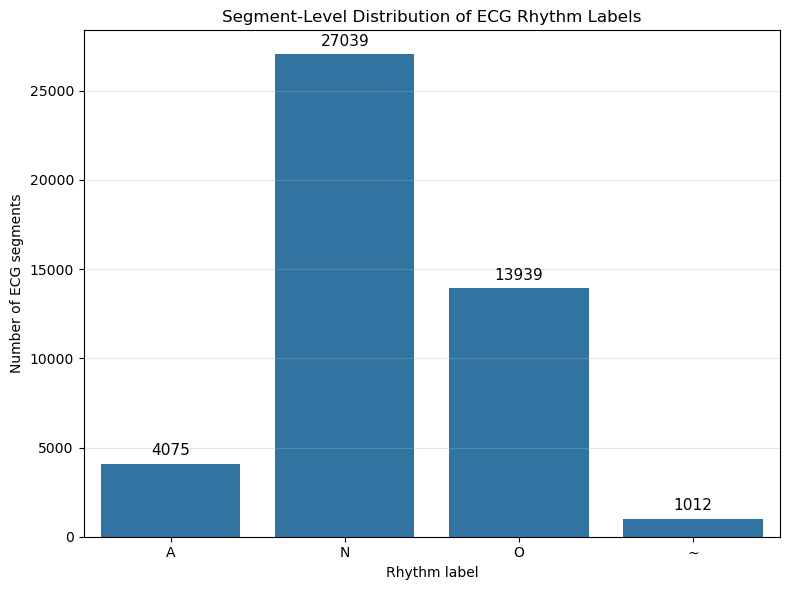

In [18]:
# 12. Target class distribution

# Count the number of ECG segments per rhythm label
label_counts = features_df["label"].value_counts().sort_index()

print("Segment-level label distribution:")
print(label_counts)

# Plot segment-level class distribution
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=features_df,
    x="label",
    order=label_counts.index
)

# Add count labels above each bar
for patch in ax.patches:
    count = int(patch.get_height())
    ax.annotate(
        f"{count}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.title("Segment-Level Distribution of ECG Rhythm Labels")
plt.xlabel("Rhythm label")
plt.ylabel("Number of ECG segments")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Check Highly Correlated ECG Features

This section checks whether any engineered ECG features are highly correlated with each other. Highly correlated features may provide overlapping information, which is useful to know before model training and interpretation.

In [19]:
# Check highly correlated ECG features

# Compute absolute pairwise correlations among ECG feature columns
correlation_matrix = features_df[feature_columns].corr().abs()

# Keep only the upper triangle of the correlation matrix
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Extract feature pairs with high correlation
high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["correlation"] >= 0.80
].sort_values(by="correlation", ascending=False)

print("Highly correlated feature pairs with correlation >= 0.80:")
high_corr_pairs

Highly correlated feature pairs with correlation >= 0.80:


,feature_1,feature_2,correlation
67,std_dev,amplitude_sd,1.000000
107,total_power,signal_energy,0.999994
16,sdnn,rmssd,0.968432
69,std_dev,signal_energy,0.965493
134,amplitude_sd,signal_energy,0.965493
105,total_power,amplitude_sd,0.965415
61,std_dev,total_power,0.965415
37,rmssd,poincare_sd1,0.961391
23,sdnn,poincare_sd1,0.938702
24,sdnn,poincare_sd2,0.927962


The correlation analysis shows that some engineered ECG features are highly redundant. For example, `std_dev` and `amplitude_sd` are perfectly correlated because both represent signal variability, while `total_power` and `signal_energy` are nearly identical. RR-variability features such as `sdnn`, `rmssd`, and Poincaré measures are also strongly correlated. These correlations suggest that some features provide overlapping information. They were retained for this exploratory model comparison, but future work could remove redundant features or use feature selection to simplify the model.

Univariate Distribution of Extracted ECG Features

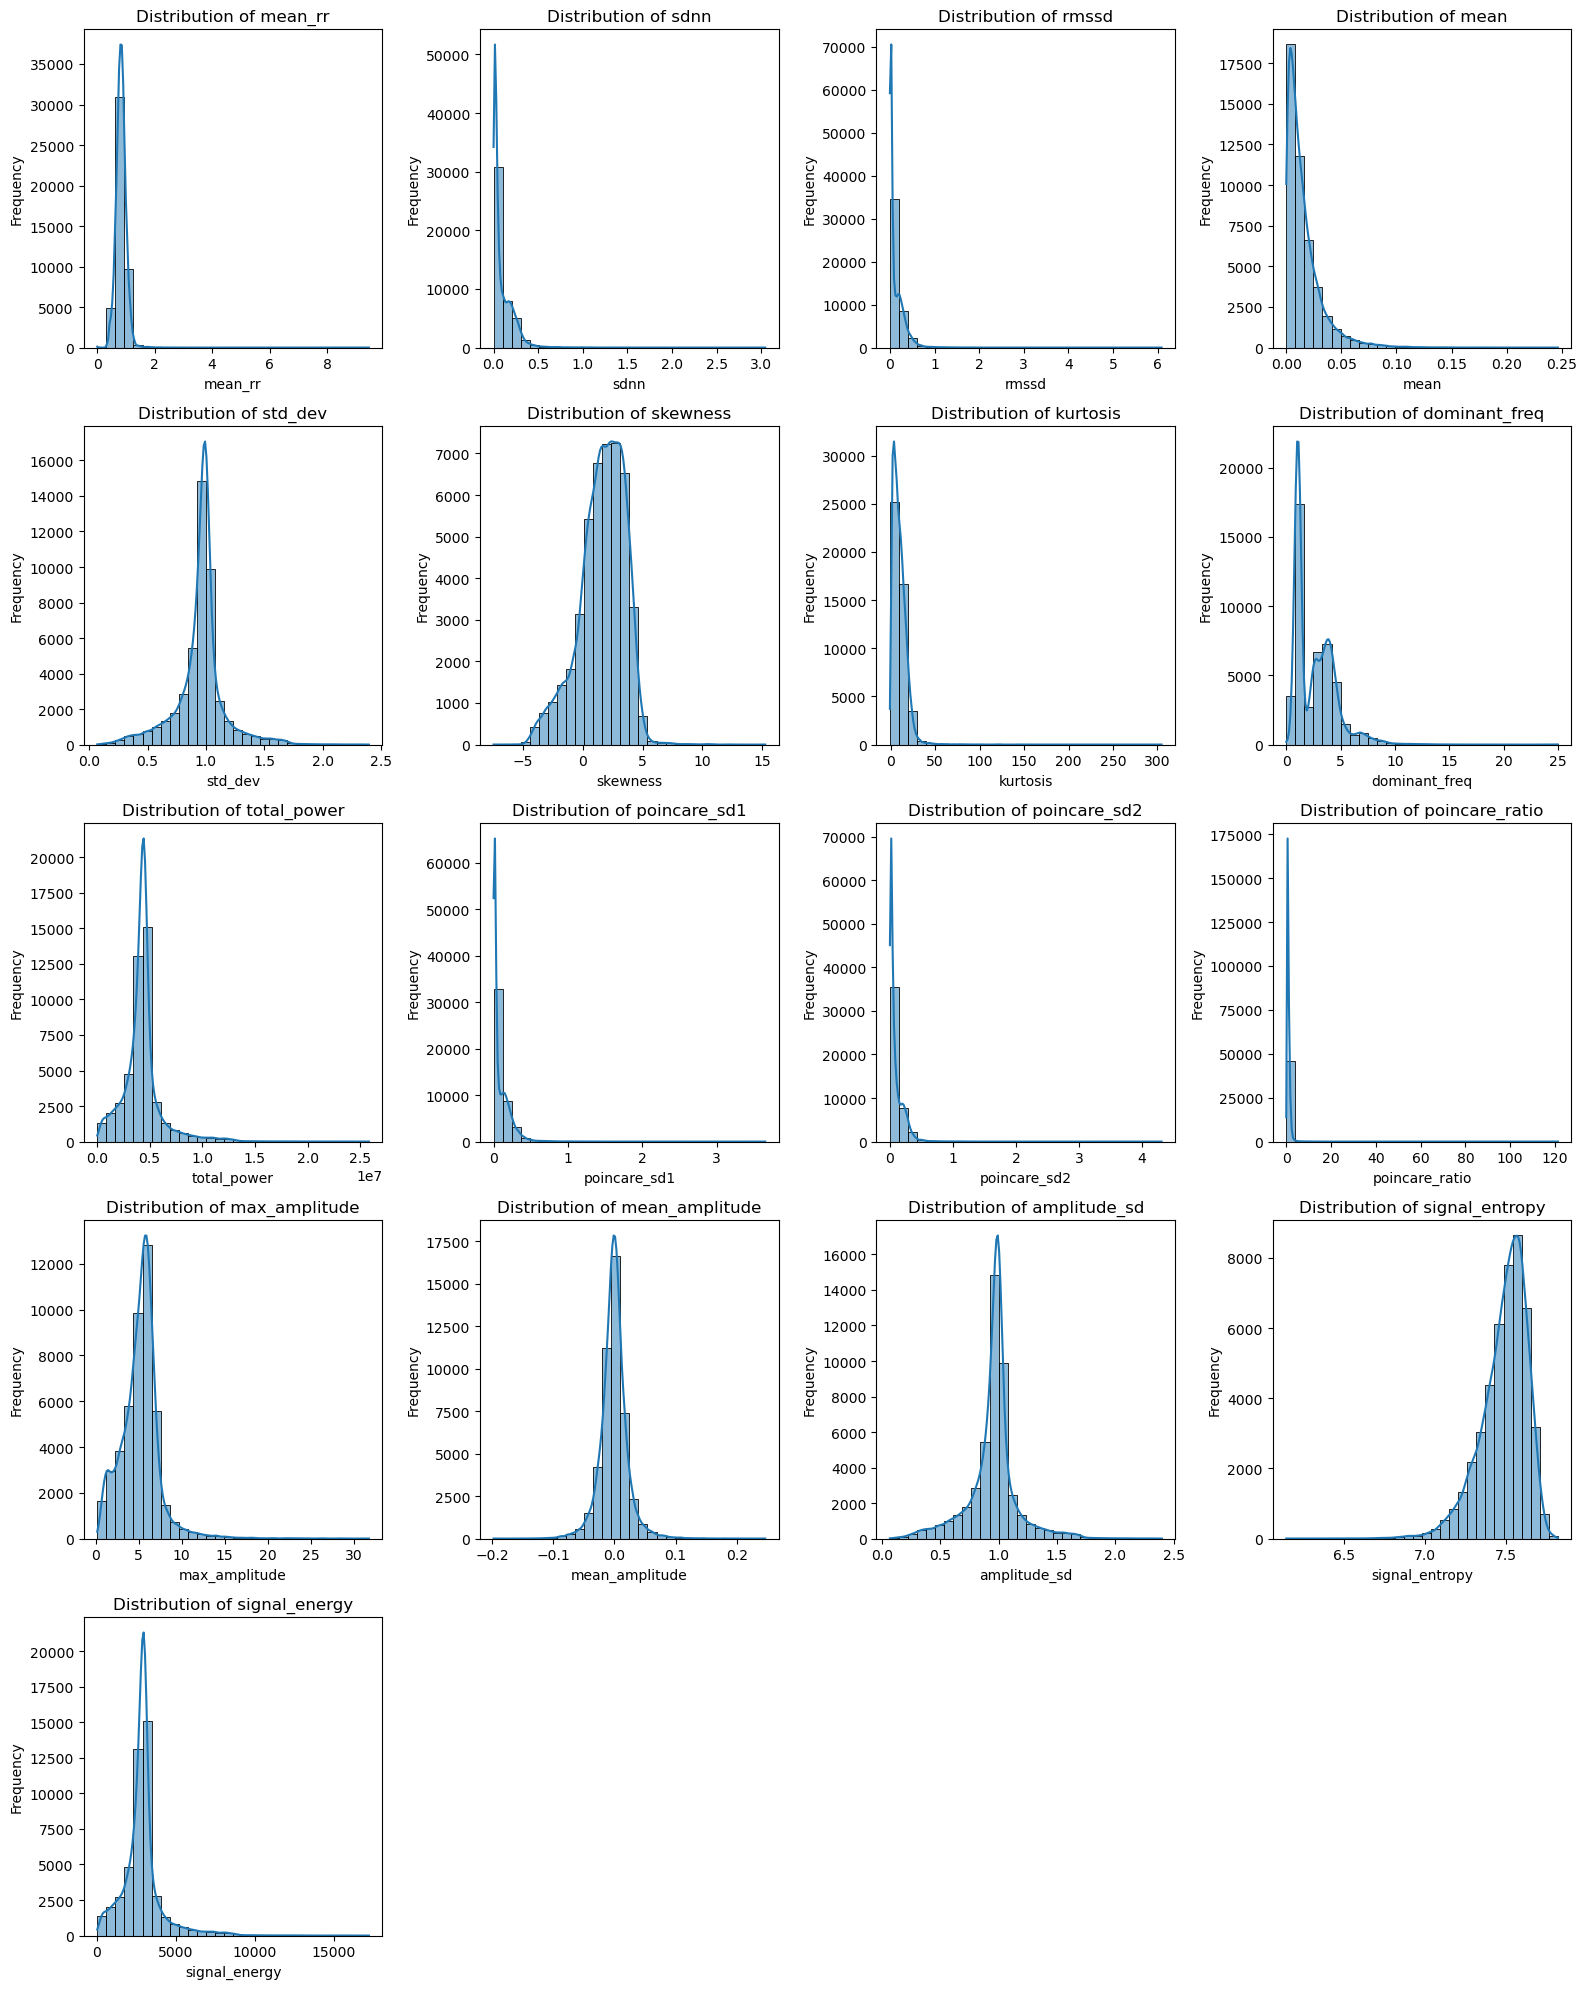

In [20]:
# Univariate distribution of extracted ECG features

# Plot histograms for extracted ECG feature columns only
num_features = len(feature_columns)
num_cols = 4
num_rows = math.ceil(num_features / num_cols)

plt.figure(figsize=(16, 4 * num_rows))

for i, column in enumerate(feature_columns):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(
        features_df[column],
        bins=30,
        kde=True
    )
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The univariate distributions show that several ECG-derived features are right-skewed, particularly RR-variability features such as `sdnn`, `rmssd`, `poincare_sd1`, `poincare_sd2`, and `poincare_ratio`, as well as power- and energy-based features such as `total_power` and `signal_energy`. This suggests that most ECG segments have relatively low-to-moderate variability, while a smaller number of segments show much larger variability or signal magnitude. Amplitude-related features such as `std_dev`, `amplitude_sd`, and `mean_amplitude` are more tightly concentrated, while `signal_entropy` is also relatively concentrated around a narrow range. Overall, these distributions show that the engineered ECG features have different scales and some skewness, supporting the decision to apply feature scaling later during model training and to evaluate models using methods that can handle non-normal feature distributions.


Bivariate Analysis with Target Variable

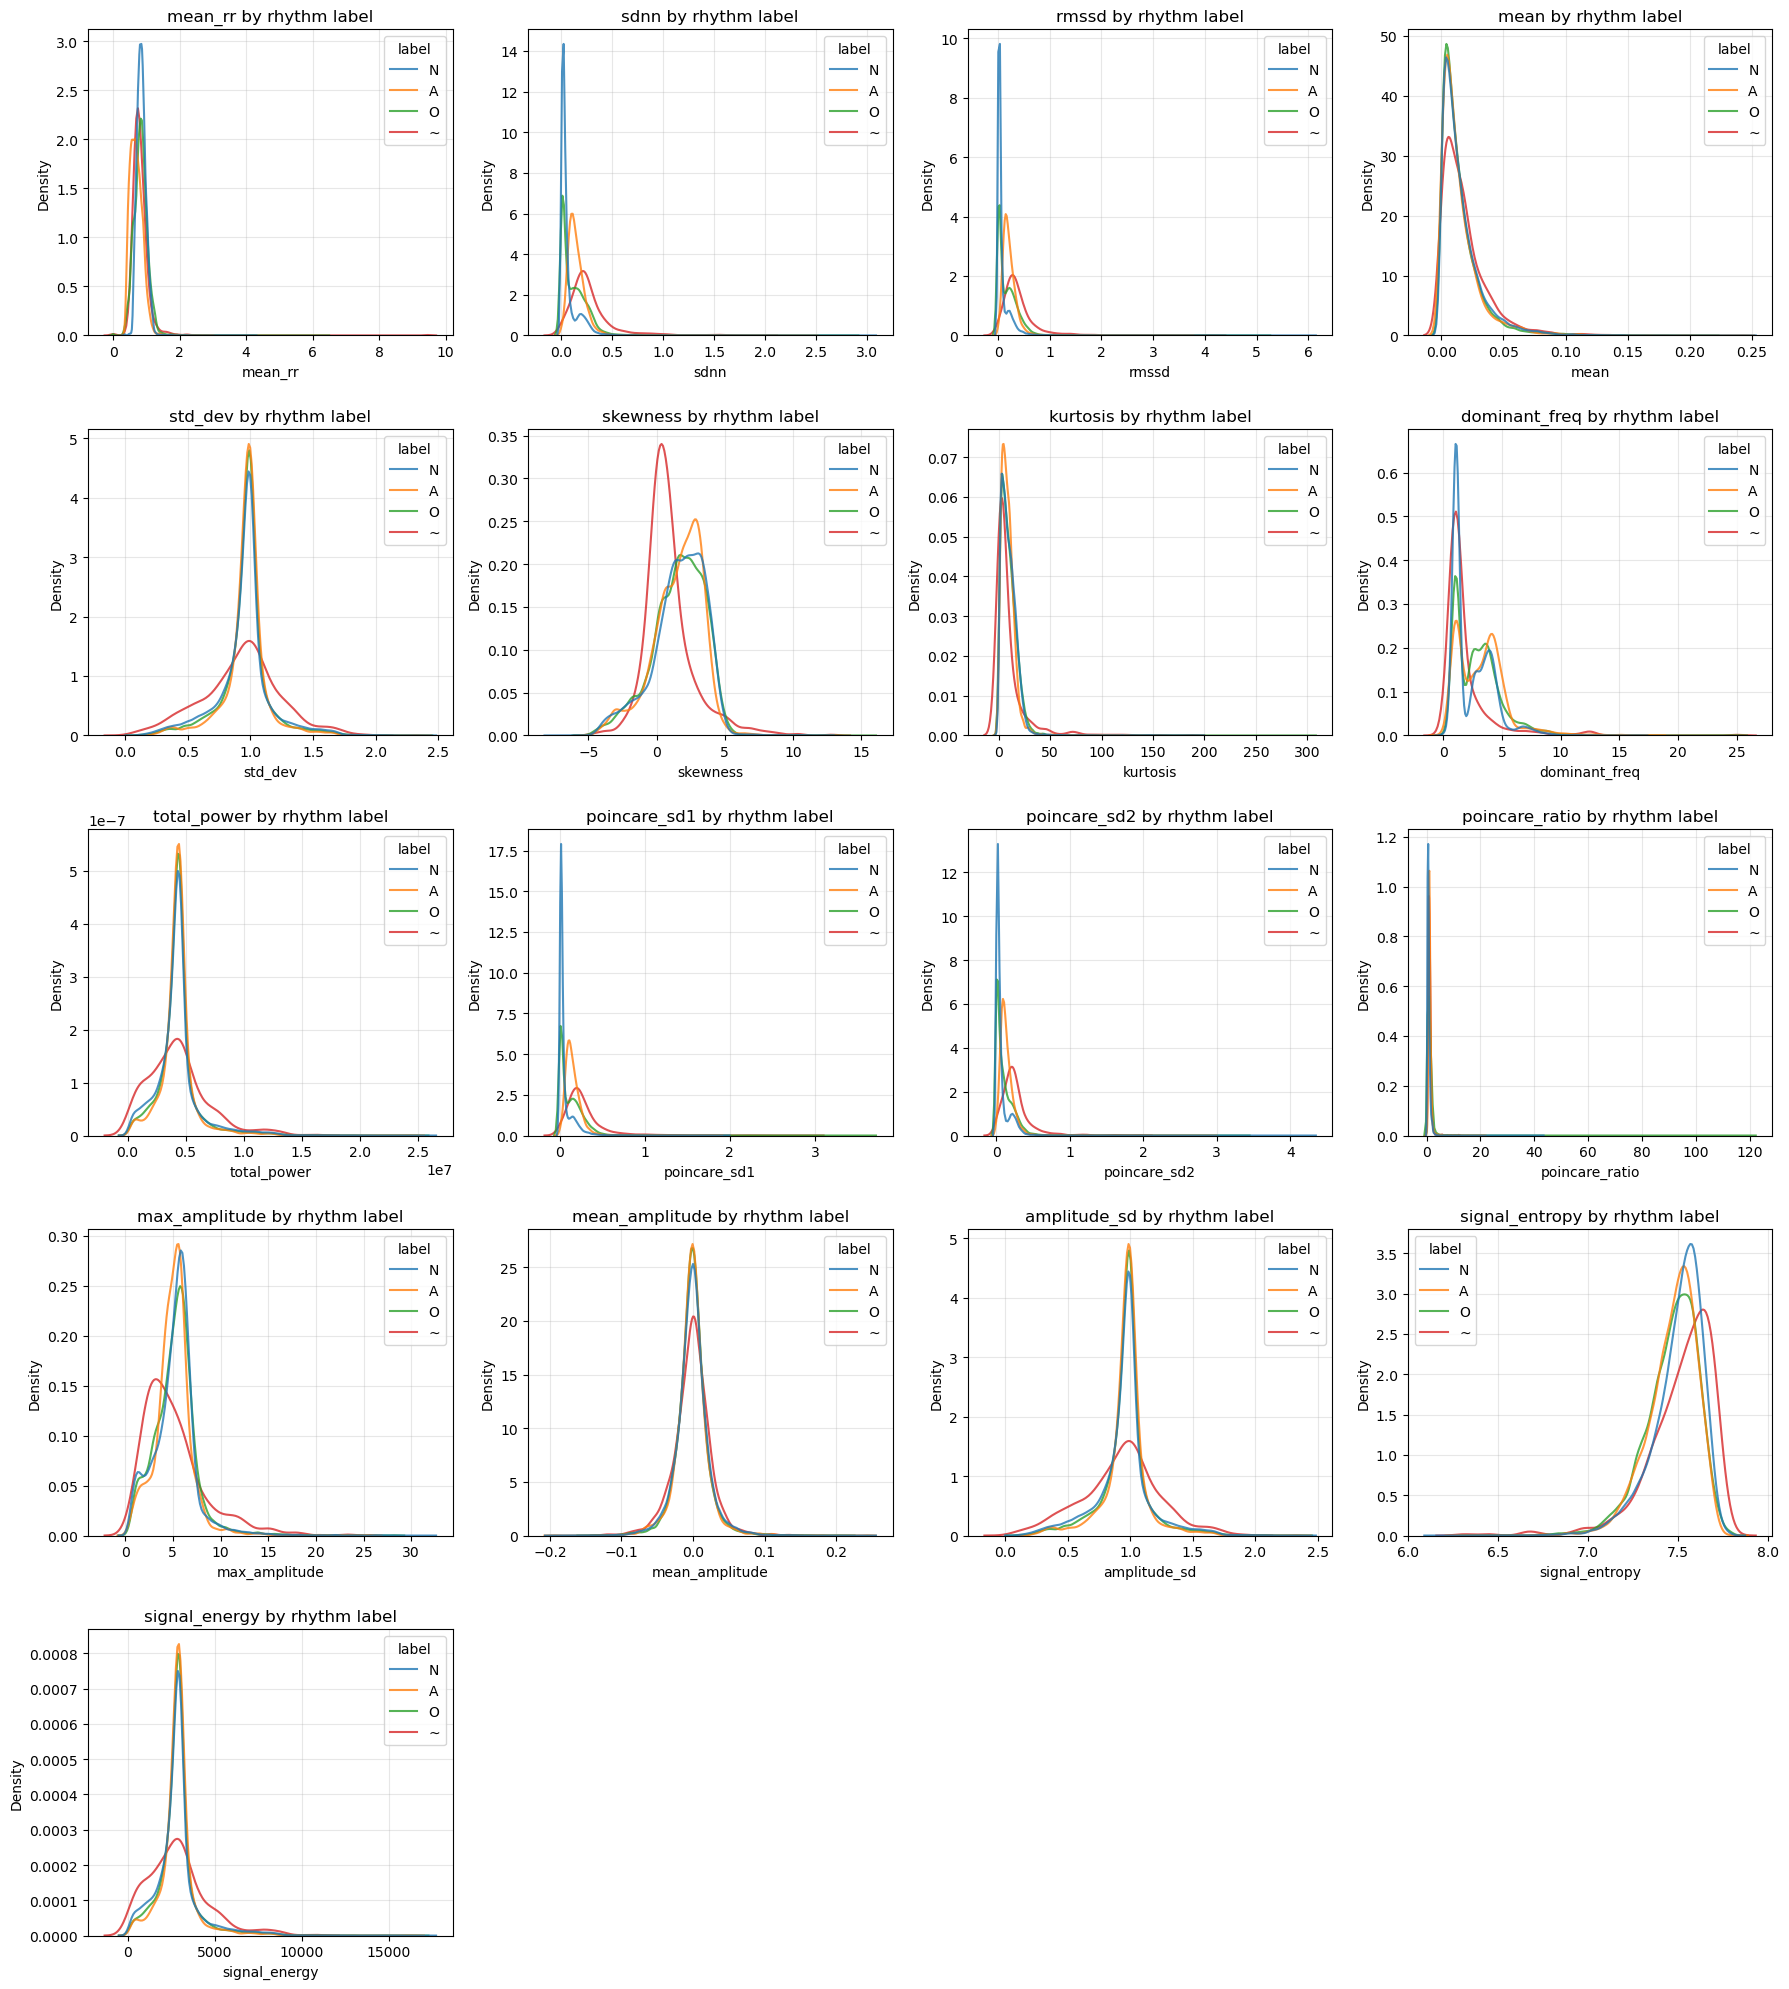

In [21]:
# Bivariate analysis: feature distributions by rhythm label

# Use only extracted ECG feature columns, excluding record, segment_id, and label
num_plots = len(feature_columns)
num_cols = 4
num_rows = math.ceil(num_plots / num_cols)

plt.figure(figsize=(18, 4 * num_rows))

for i, column in enumerate(feature_columns):
    plt.subplot(num_rows, num_cols, i + 1)

    sns.kdeplot(
        data=features_df,
        x=column,
        hue="label",
        fill=False,
        common_norm=False,
        alpha=0.8
    )

    plt.title(f"{column} by rhythm label")
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The bivariate density plots show that several engineered ECG features have overlapping distributions across rhythm labels, suggesting that no single feature clearly separates all rhythm categories. However, some class-level differences are visible in RR-variability features such as `sdnn`, `rmssd`, `poincare_sd1`, and `poincare_sd2`, where atrial fibrillation and noisy recordings appear to have broader or shifted distributions compared with normal rhythm. Frequency- and signal-complexity features such as `dominant_freq`, `signal_entropy`, `signal_energy`, and amplitude-related measures also show some separation across labels, but with substantial overlap. Overall, these patterns support using multivariable machine-learning models that combine information across multiple ECG features rather than relying on a single predictor.


Record-Level Train/Test Split and Feature Scaling

This section creates the modeling dataset and splits it into training and testing sets. Because each ECG recording was divided into multiple overlapping windows, the split is performed at the ECG record level rather than the segment level. This prevents segments from the same ECG recording from appearing in both training and testing sets.

After the split, feature scaling is fit only on the training data and then applied to both the training and test sets. This avoids information leakage from the test set into preprocessing.

In [ ]:
# Record-level train/test split and feature scaling

# Each row in features_df is one ECG segment.
# The record column identifies which original ECG recording each segment came from.
# We split by record so that all segments from the same ECG recording stay together.

record_label_df = (
    features_df[["record", "label"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Safety check: each ECG record should have only one label
records_with_multiple_labels = (
    record_label_df.groupby("record")["label"].nunique()
    .loc[lambda x: x > 1]
)

if len(records_with_multiple_labels) > 0:
    raise ValueError("Some ECG records have more than one label. Please check the label file.")

# Keep one label per ECG record for stratified record-level splitting
record_label_df = (
    record_label_df
    .drop_duplicates(subset=["record"])
    .reset_index(drop=True)
)

# Split ECG records into train and test sets while preserving label proportions
train_records, test_records = train_test_split(
    record_label_df,
    test_size=0.20,
    stratify=record_label_df["label"],
    random_state=RANDOM_STATE
)

# Subset the segment-level feature table using the selected train/test records
train_df = features_df[features_df["record"].isin(train_records["record"])].copy()
test_df = features_df[features_df["record"].isin(test_records["record"])].copy()

# Separate predictors and outcome labels
X_train_raw = train_df[feature_columns].copy()
X_test_raw = test_df[feature_columns].copy()

y_train_raw = train_df["label"].copy()
y_test_raw = test_df["label"].copy()

# Keep record identifiers for possible grouped validation or error analysis
groups_train = train_df["record"].copy()
groups_test = test_df["record"].copy()

# Encode target labels after splitting
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

print("Label encoding:")
for original_label, encoded_label in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{original_label} -> {encoded_label}")

# Check missing values after splitting
train_missing = X_train_raw.isnull().sum().sum()
test_missing = X_test_raw.isnull().sum().sum()

print("\nMissing values in X_train before scaling:", train_missing)
print("Missing values in X_test before scaling:", test_missing)

# If missing values are present, impute using training-set medians only
if train_missing > 0 or test_missing > 0:
    train_medians = X_train_raw.median()
    X_train_raw = X_train_raw.fillna(train_medians)
    X_test_raw = X_test_raw.fillna(train_medians)
    print("Missing values were imputed using training-set medians.")
else:
    print("No missing values found. Imputation was not applied.")

# Scale features using training data only
scaler = MinMaxScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=feature_columns,
    index=X_train_raw.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=feature_columns,
    index=X_test_raw.index
)

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training label shape:", y_train.shape)
print("Testing label shape:", y_test.shape)

print("\nNumber of training ECG records:", train_df["record"].nunique())
print("Number of testing ECG records:", test_df["record"].nunique())

Label encoding:
A -> 0
N -> 1
O -> 2
~ -> 3

Missing values in X_train before scaling: 0
Missing values in X_test before scaling: 0
No missing values found. Imputation was not applied.

Training feature shape: (36791, 17)
Testing feature shape: (9274, 17)
Training label shape: (36791,)
Testing label shape: (9274,)

Number of training ECG records: 6809
Number of testing ECG records: 1703


Segment-level class distribution after record-level split:


,Training segments,Testing segments
label,,
A,3256,819
N,21586,5453
O,11125,2814
~,824,188


Record-level class distribution after record-level split:


,Training records,Testing records
label,,
A,606,151
N,4052,1014
O,1929,482
~,222,56


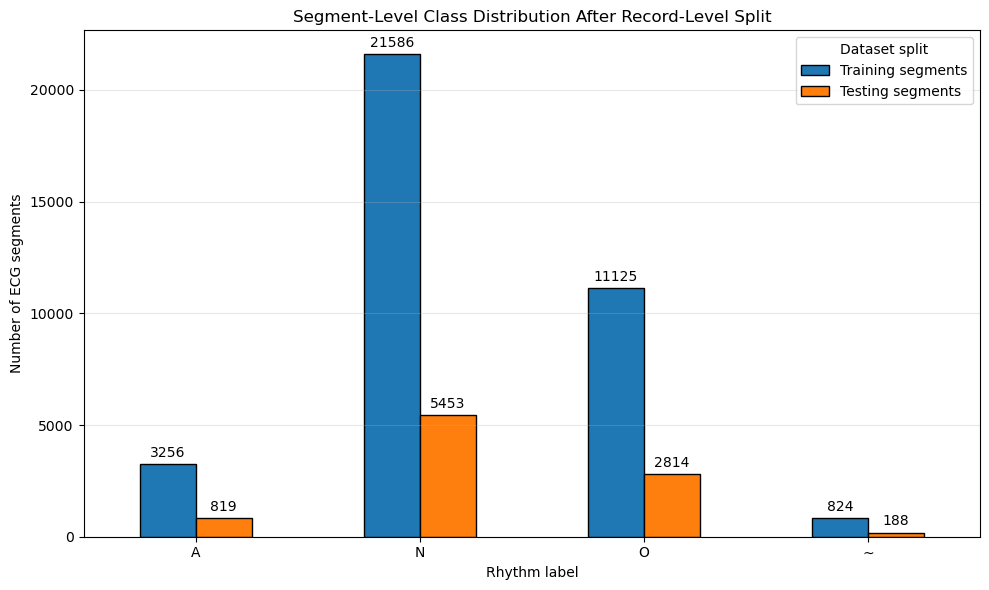

In [23]:
# Check class distribution after record-level split

# Segment-level class counts after splitting
train_segment_counts = y_train_raw.value_counts().sort_index()
test_segment_counts = y_test_raw.value_counts().sort_index()

segment_class_counts_df = pd.DataFrame({
    "Training segments": train_segment_counts,
    "Testing segments": test_segment_counts
}).fillna(0).astype(int)

print("Segment-level class distribution after record-level split:")
display(segment_class_counts_df)

# Record-level class counts after splitting
train_record_counts = train_records["label"].value_counts().sort_index()
test_record_counts = test_records["label"].value_counts().sort_index()

record_class_counts_df = pd.DataFrame({
    "Training records": train_record_counts,
    "Testing records": test_record_counts
}).fillna(0).astype(int)

print("Record-level class distribution after record-level split:")
display(record_class_counts_df)

# Plot segment-level class distribution
ax = segment_class_counts_df.plot(
    kind="bar",
    figsize=(10, 6),
    edgecolor="black"
)

plt.title("Segment-Level Class Distribution After Record-Level Split")
plt.xlabel("Rhythm label")
plt.ylabel("Number of ECG segments")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Dataset split")

for container in ax.containers:
    ax.bar_label(container, label_type="edge", fontsize=10, padding=3)

plt.tight_layout()
plt.show()

The record-level train-test split produced 6,809 training ECG records and 1,703 testing ECG records. After expanding records into ECG segments, the training set contained 36,791 segments and the testing set contained 9,274 segments. No missing feature values were present in either split, so imputation was not applied. Feature scaling was fit only on the training data and then applied to the test data to avoid information leakage. The class distributions at both the segment and record levels show that the stratified split preserved the overall rhythm-label balance reasonably well across training and testing sets.

Linear Support Vector Machine

In [24]:
# Model evaluation helper function

def evaluate_model(model_name, y_true, y_pred, label_encoder):
    """
    Evaluate a classification model using overall and class-specific metrics.

    Parameters
    ----------
    model_name : str
        Name of the model being evaluated.
    y_true : array-like
        True encoded labels.
    y_pred : array-like
        Predicted encoded labels.
    label_encoder : LabelEncoder
        Fitted label encoder used to map encoded labels back to original class names.

    Returns
    -------
    dict
        Dictionary containing summary performance metrics.
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    metrics_table = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Weighted precision",
            "Weighted recall",
            "Weighted F1 score"
        ],
        "Score": [
            accuracy,
            precision,
            recall,
            f1
        ]
    })

    print(f"\n{model_name} Metrics:")
    display(metrics_table)

    print(f"\n{model_name} Classification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

    conf_matrix = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Weighted Precision": precision,
        "Weighted Recall": recall,
        "Weighted F1": f1
    }


Linear SVM Metrics:


,Metric,Score
0,Accuracy,0.639853
1,Weighted precision,0.663131
2,Weighted recall,0.639853
3,Weighted F1 score,0.620950



Linear SVM Classification Report:
              precision    recall  f1-score   support

           A       0.41      0.58      0.48       819
           N       0.75      0.87      0.80      5453
           O       0.61      0.24      0.34      2814
           ~       0.10      0.37      0.16       188

    accuracy                           0.64      9274
   macro avg       0.47      0.51      0.45      9274
weighted avg       0.66      0.64      0.62      9274



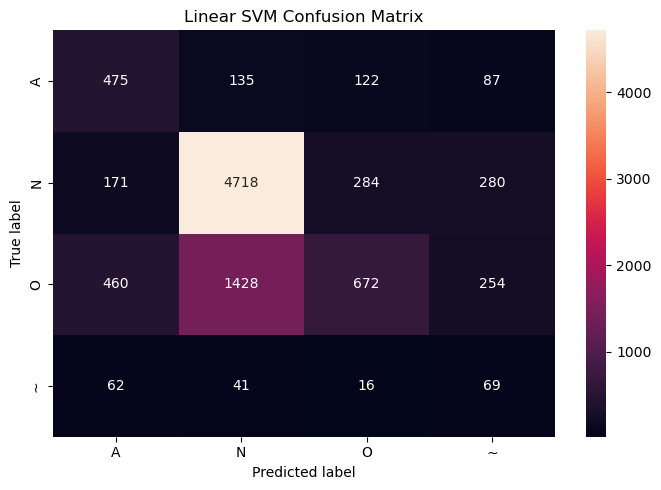

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1
0,Linear SVM,0.639853,0.663131,0.639853,0.62095


In [25]:

# Linear Support Vector Machine 
linear_svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter=5000
)

linear_svm.fit(X_train, y_train)

y_pred_svm = linear_svm.predict(X_test)

svm_result = evaluate_model(
    "Linear SVM",
    y_test,
    y_pred_svm,
    label_encoder
)

svm_results_df = pd.DataFrame([svm_result])
svm_results_df

The Linear SVM baseline achieved an overall accuracy of 0.64 and a weighted F1 score of 0.62 on the record-level test set. The model performed best for normal rhythm (`N`), with high recall, but had weaker performance for `O` and noisy (`~`) recordings. Atrial fibrillation (`A`) showed moderate recall, meaning the model identified a reasonable portion of AF segments, but precision was lower due to false positives. The confusion matrix also shows that many `O` segments were misclassified as normal rhythm, suggesting overlap between the engineered feature distributions for these classes. Overall, Linear SVM provides a useful baseline, but the results indicate that a nonlinear model such as LightGBM may better capture feature interactions in this ECG dataset.


Weighted one-vs-rest ROC-AUC: 0.7522


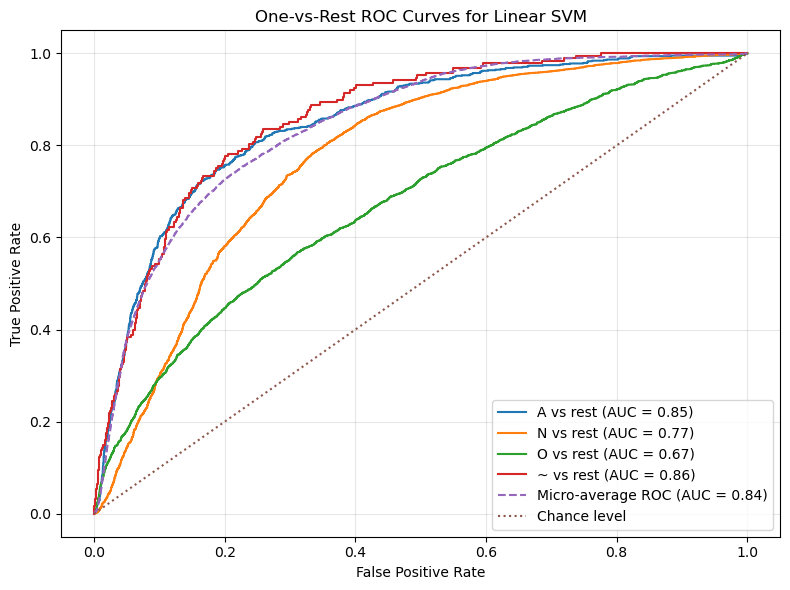

In [26]:
# ROC curve for Linear SVM

# Binarize true test labels for one-vs-rest ROC calculation
y_test_binarized = label_binarize(
    y_test,
    classes=np.arange(len(label_encoder.classes_))
)

# Get decision scores from LinearSVC.
# LinearSVC does not produce predicted probabilities by default,
# so ROC curves are based on decision scores.
y_score_svm = linear_svm.decision_function(X_test)

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i, class_label in enumerate(label_encoder.classes_):
    fpr[i], tpr[i], _ = roc_curve(
        y_test_binarized[:, i],
        y_score_svm[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_binarized.ravel(),
    y_score_svm.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute weighted one-vs-rest ROC-AUC manually
# This is used because LinearSVC provides decision scores rather than probabilities.
class_support = np.bincount(
    y_test,
    minlength=len(label_encoder.classes_)
)

weighted_roc_auc_svm = np.average(
    [roc_auc[i] for i in range(len(label_encoder.classes_))],
    weights=class_support
)

print(f"Weighted one-vs-rest ROC-AUC: {weighted_roc_auc_svm:.4f}")

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i, class_label in enumerate(label_encoder.classes_):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_label} vs rest (AUC = {roc_auc[i]:.2f})"
    )

plt.plot(
    fpr["micro"],
    tpr["micro"],
    linestyle="--",
    label=f"Micro-average ROC (AUC = {roc_auc['micro']:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    label="Chance level"
)

plt.title("One-vs-Rest ROC Curves for Linear SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



LightGBM Classifier

This section trains a LightGBM classifier on the engineered ECG feature dataset. LightGBM is a gradient boosting decision-tree model that can capture nonlinear relationships and interactions among ECG-derived features.

Because the rhythm labels are imbalanced, moderated class weights are calculated from the training data. These weights account for class imbalance while avoiding overly aggressive weighting of minority classes.

Moderated class weights:
{0: 1.6807325169734157, 1: 0.6527617741917884, 2: 0.9092656624682471, 3: 3.3410055314478377}

LightGBM with Moderated Class Weights Metrics:


,Metric,Score
0,Accuracy,0.718245
1,Weighted precision,0.712656
2,Weighted recall,0.718245
3,Weighted F1 score,0.711516



LightGBM with Moderated Class Weights Classification Report:
              precision    recall  f1-score   support

           A       0.55      0.55      0.55       819
           N       0.80      0.87      0.83      5453
           O       0.63      0.49      0.55      2814
           ~       0.24      0.35      0.28       188

    accuracy                           0.72      9274
   macro avg       0.55      0.57      0.55      9274
weighted avg       0.71      0.72      0.71      9274



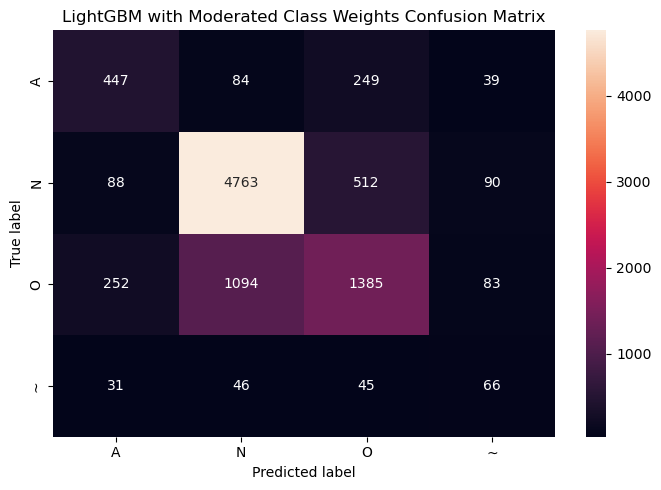

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1
0,LightGBM with Moderated Class Weights,0.718245,0.712656,0.718245,0.711516


In [27]:
# Fast LightGBM classifier

# Compute class weights from the training labels to address class imbalance

classes = np.unique(y_train)

balanced_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Square-root weights reduce extreme weighting for minority classes
sqrt_class_weight_dict = {
    cls: np.sqrt(weight)
    for cls, weight in zip(classes, balanced_weights)
}

print("Moderated class weights:")
print(sqrt_class_weight_dict)

lgbm_moderated = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(label_encoder.classes_),
    class_weight=sqrt_class_weight_dict,
    random_state=RANDOM_STATE,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    n_jobs=-1,
    verbosity=-1
)

lgbm_moderated.fit(X_train_raw, y_train)

y_pred_lgbm_moderated = lgbm_moderated.predict(X_test_raw)
y_proba_lgbm_moderated = lgbm_moderated.predict_proba(X_test_raw)

lgbm_moderated_result = evaluate_model(
    "LightGBM with Moderated Class Weights",
    y_test,
    y_pred_lgbm_moderated,
    label_encoder
)

lgbm_moderated_results_df = pd.DataFrame([lgbm_moderated_result])
lgbm_moderated_results_df

The LightGBM model with moderated class weights achieved an accuracy of 0.72 and a weighted F1 score of 0.71 on the record-level test set. The model performed best for normal rhythm (`N`), with strong recall and F1 score, while atrial fibrillation (`A`) and other rhythm (`O`) showed moderate performance. The noisy class (`~`) remained the most difficult because it had the smallest number of test samples and substantial overlap with other classes. The moderated class weights helped account for imbalance without overemphasizing the minority classes too aggressively. Overall, LightGBM provided a strong nonlinear baseline for the engineered ECG features and performed nearly as well as the final hybrid model.


Weighted one-vs-rest ROC-AUC: 0.8287


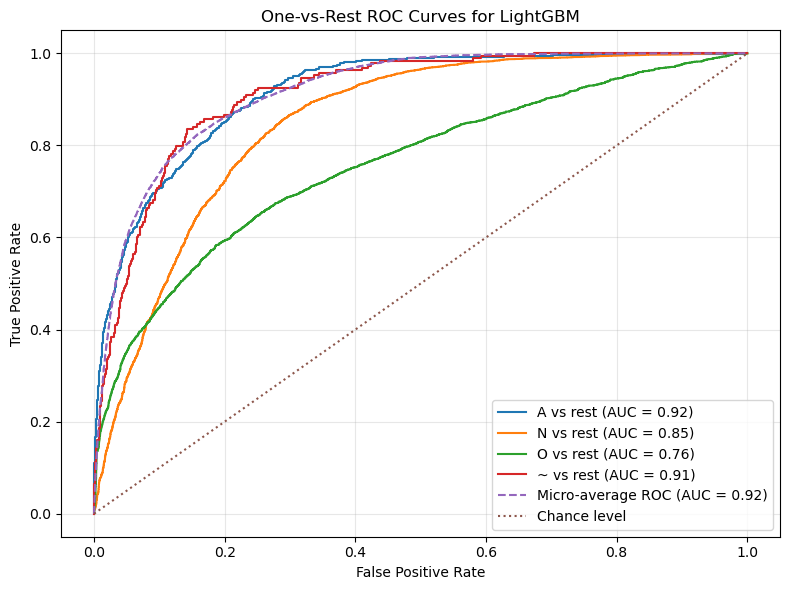

In [28]:
# ROC curves for LightGBM with moderated class weights

y_test_binarized = label_binarize(
    y_test,
    classes=np.arange(len(label_encoder.classes_))
)

fpr = {}
tpr = {}
roc_auc = {}

for i, class_label in enumerate(label_encoder.classes_):
    fpr[i], tpr[i], _ = roc_curve(
        y_test_binarized[:, i],
        y_proba_lgbm_moderated[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_binarized.ravel(),
    y_proba_lgbm_moderated.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

weighted_roc_auc = roc_auc_score(
    y_test,
    y_proba_lgbm_moderated,
    multi_class="ovr",
    average="weighted"
)

print(f"Weighted one-vs-rest ROC-AUC: {weighted_roc_auc:.4f}")

plt.figure(figsize=(8, 6))

for i, class_label in enumerate(label_encoder.classes_):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_label} vs rest (AUC = {roc_auc[i]:.2f})"
    )

plt.plot(
    fpr["micro"],
    tpr["micro"],
    linestyle="--",
    label=f"Micro-average ROC (AUC = {roc_auc['micro']:.2f})"
)

plt.plot([0, 1], [0, 1], linestyle=":", label="Chance level")

plt.title("One-vs-Rest ROC Curves for LightGBM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Hybrid SVM–LightGBM Model with Moderated Class Weights

This section creates a hybrid model by combining the Linear SVM baseline with the LightGBM model. The SVM contributes margin-based decision scores, while LightGBM contributes nonlinear predicted class probabilities.

The hybrid uses normalized SVM decision scores and LightGBM predicted probabilities rather than averaging encoded class labels.


Hybrid SVM-LightGBM with Moderated Class Weights Metrics:


,Metric,Score
0,Accuracy,0.720293
1,Weighted precision,0.715349
2,Weighted recall,0.720293
3,Weighted F1 score,0.713245



Hybrid SVM-LightGBM with Moderated Class Weights Classification Report:
              precision    recall  f1-score   support

           A       0.55      0.54      0.55       819
           N       0.80      0.88      0.83      5453
           O       0.64      0.49      0.56      2814
           ~       0.24      0.37      0.29       188

    accuracy                           0.72      9274
   macro avg       0.56      0.57      0.56      9274
weighted avg       0.72      0.72      0.71      9274



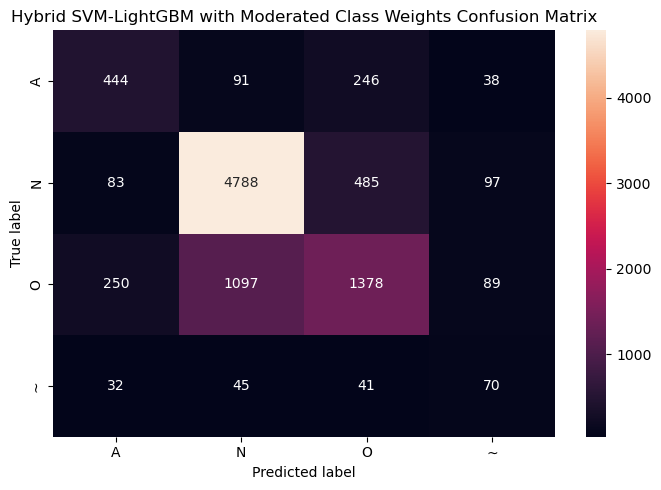

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1
0,Hybrid SVM-LightGBM with Moderated Class Weights,0.720293,0.715349,0.720293,0.713245


In [29]:
# Hybrid SVM-LightGBM model with moderated class weights


def softmax_scores(scores):
    """
    Convert model decision scores into normalized class scores.

    LinearSVC provides decision scores rather than predicted probabilities.
    Softmax converts these scores into probability-like normalized values.
    """
    scores = np.asarray(scores)
    scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(scores)

    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


# Get Linear SVM decision scores on the scaled test set
svm_decision_scores = linear_svm.decision_function(X_test)

# Convert Linear SVM decision scores into normalized class scores
svm_score_normalized = softmax_scores(svm_decision_scores)

# Get predicted probabilities from the moderated LightGBM model
lgbm_moderated_probabilities = lgbm_moderated.predict_proba(X_test_raw)

# Combine Linear SVM and moderated LightGBM outputs.
# LightGBM is given higher weight because it performed better individually.
svm_weight = 0.20
lgbm_weight = 0.80

hybrid_moderated_probabilities = (
    svm_weight * svm_score_normalized
    + lgbm_weight * lgbm_moderated_probabilities
)

# Final hybrid predictions
y_pred_hybrid_moderated = np.argmax(hybrid_moderated_probabilities, axis=1)

# Evaluate hybrid model
hybrid_moderated_result = evaluate_model(
    "Hybrid SVM-LightGBM with Moderated Class Weights",
    y_test,
    y_pred_hybrid_moderated,
    label_encoder
)

hybrid_moderated_results_df = pd.DataFrame([hybrid_moderated_result])
hybrid_moderated_results_df

The Hybrid SVM–LightGBM model with moderated class weights achieved an overall accuracy of 0.72 and a weighted F1 score of 0.71 on the record-level test set. The model performed strongest for normal rhythm (`N`), with high recall, while atrial fibrillation (`A`) and other rhythm (`O`) showed moderate performance. The noisy class (`~`) remained the most difficult to classify because it had the smallest support and substantial overlap with other classes, resulting in low precision despite improved recall. The confusion matrix shows that many `O` segments were misclassified as normal rhythm, suggesting that some rhythm categories share similar engineered ECG feature patterns. Overall, the hybrid model provided the best performance among the tested models, but the results should be interpreted as exploratory model-comparison findings rather than clinical validation.


Weighted one-vs-rest ROC-AUC: 0.8291


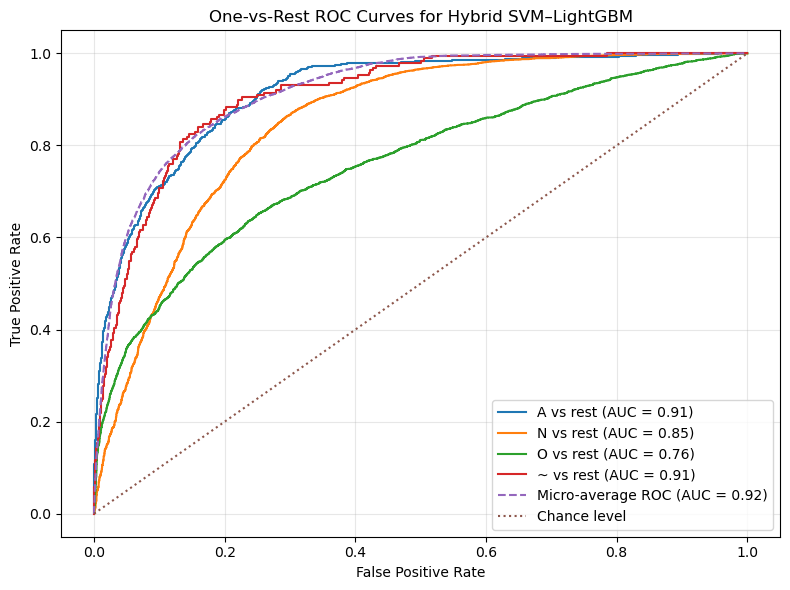

In [30]:
# ROC curves for Hybrid SVM-LightGBM

# Binarize true test labels for one-vs-rest ROC calculation
y_test_binarized = label_binarize(
    y_test,
    classes=np.arange(len(label_encoder.classes_))
)

# Use hybrid model probabilities from the final hybrid model
y_score_hybrid = hybrid_moderated_probabilities

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i, class_label in enumerate(label_encoder.classes_):
    fpr[i], tpr[i], _ = roc_curve(
        y_test_binarized[:, i],
        y_score_hybrid[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_binarized.ravel(),
    y_score_hybrid.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute weighted multiclass ROC-AUC
weighted_roc_auc_hybrid = roc_auc_score(
    y_test,
    y_score_hybrid,
    multi_class="ovr",
    average="weighted"
)

print(f"Weighted one-vs-rest ROC-AUC: {weighted_roc_auc_hybrid:.4f}")

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i, class_label in enumerate(label_encoder.classes_):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_label} vs rest (AUC = {roc_auc[i]:.2f})"
    )

plt.plot(
    fpr["micro"],
    tpr["micro"],
    linestyle="--",
    label=f"Micro-average ROC (AUC = {roc_auc['micro']:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    label="Chance level"
)

plt.title("One-vs-Rest ROC Curves for Hybrid SVM–LightGBM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The one-vs-rest ROC curves show how well the hybrid model separates each rhythm class from the remaining classes across different thresholds. Because this is an imbalanced multiclass problem, ROC-AUC is interpreted together with the confusion matrix, precision, recall, and F1 score.

In [31]:
# Model comparison summary

model_comparison_df = pd.DataFrame([
    svm_result,
    lgbm_moderated_result,
    hybrid_moderated_result
])

model_comparison_df = model_comparison_df.sort_values(
    by="Weighted F1",
    ascending=False
).reset_index(drop=True)

model_comparison_df

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1
0,Hybrid SVM-LightGBM with Moderated Class Weights,0.720293,0.715349,0.720293,0.713245
1,LightGBM with Moderated Class Weights,0.718245,0.712656,0.718245,0.711516
2,Linear SVM,0.639853,0.663131,0.639853,0.620950


Final Model Comparison

The final model comparison shows that the Hybrid SVM–LightGBM model achieved the best overall performance, with an accuracy of 0.72 and a weighted F1 score of 0.71 on the record-level test set. LightGBM with moderated class weights performed very similarly, suggesting that most of the predictive signal came from the nonlinear gradient-boosting model. The Linear SVM baseline had lower performance, indicating that a linear decision boundary was less effective for these engineered ECG features. Overall, the hybrid model provided a modest improvement over LightGBM alone, but the difference was small, so the results should be interpreted as an exploratory model comparison rather than clinical validation.

### Limitations, Scope, Generalizability, and Future Work

#### Limitations

This project is an exploratory machine-learning analysis using engineered features from short single-lead ECG recordings.

The dataset contains class imbalance, with normal rhythm having the largest number of samples and noisy recordings having the smallest support. This imbalance affects class-specific performance, especially for the noisy class. Moderated class weights were used to account for imbalance while avoiding overly aggressive weighting of minority classes, but minority-class precision and recall remained lower and more variable than performance for normal rhythm.

Another limitation is that the model relies on engineered ECG features such as RR-interval variability, frequency-domain features, amplitude-based features, entropy, and Poincaré measures. These features are interpretable, but they may not capture all complex waveform morphology patterns present in raw ECG signals. In addition, several features depend on accurate R-peak detection, so noisy or irregular recordings may produce less reliable feature estimates.

#### Scope and Generalizability

The scope of this project is limited to exploratory rhythm classification using the PhysioNet/CinC 2017 short single-lead ECG dataset. The analysis demonstrates that feature-based machine-learning models can identify useful patterns across rhythm categories, but the results should not be interpreted as clinical validation.

Generalizability may be limited because the analysis uses one public ECG dataset with a specific recording format, sampling rate, label structure, and preprocessing workflow. Model performance may differ across other ECG devices, clinical settings, patient populations, recording durations, or multi-lead ECG systems. External validation on an independent dataset would be needed before making broader claims about clinical applicability.

#### Future Work

Future work could strengthen this analysis in several ways. First, external validation or nested grouped cross-validation could be used to better estimate model performance. Second, additional ECG-specific features could be incorporated, including more detailed rhythm, morphology, and signal-quality measures. Third, model calibration and threshold-based analysis could be added to evaluate how predicted probabilities behave across clinically meaningful decision thresholds.

Future analysis could also focus specifically on atrial fibrillation detection as a binary classification task, where sensitivity, specificity, positive predictive value, and negative predictive value would be easier to interpret clinically. Deep learning models trained directly on raw ECG waveforms could also be explored if sufficient data and computational resources are available. Finally, additional error analysis would help identify why certain rhythm categories, especially other rhythm and noisy recordings, are more difficult to classify.
